# Full SST-2 DistilBERT layer sensitivity: custom INT8 PTQ vs codebook W8

This notebook repeats the complete ResNet-18 layer-sensitivity methodology on the existing fine-tuned DistilBERT classifier. Every accuracy, disagreement and selective-precision result uses the **complete labelled SST-2 development set of 872 examples**.

The two mathematical, weight-only methods use identical tensor coverage:

1. **Custom PTQ W8:** symmetric per-output-channel signed INT8.
2. **Custom codebook W8:** scalar `K=256`, `vector_dim=1` codebooks, giving one 8-bit assignment per weight.

Exactly one kernel or embedding tensor is quantized in each layer experiment; all remaining tensors retain checkpoint values. Attention bias arrays are deliberately excluded even though Keras stores them as rank-2 tensors. Activations, tokenizer outputs and Keras arithmetic remain FP32/standard integer-token inputs. No fake-quantization nodes or retraining are used.

In [1]:
from pathlib import Path
import gc
import json
import platform
import sys
import time

import keras
import keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.stats import binomtest, pearsonr, spearmanr
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Run from the project root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models import (
    DISTILBERT_BASE_EN_UNCASED_PRESET, SST2_CLASS_NAMES,
    build_distilbert_text_preprocessor,
)
from src.quantization.custom_quantization import (
    codebook_vectorize_model, custom_ptq, dequantize_tensor,
    reconstruct_codebook_tensor,
)

print(f"Python: {sys.version.split()[0]} ({sys.executable})")
print(f"TensorFlow: {tf.__version__}; Keras: {keras.__version__}; SciPy: {scipy.__version__}")

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.13.7 (/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/bin/python)
TensorFlow: 2.20.0; Keras: 3.14.1; SciPy: 1.18.0


## 1. Fixed configuration

Caches make the experiment resumable. Change `CACHE_VERSION` after changing the checkpoint or quantization mathematics.

In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "sst2" / "SST-2"
DEV_PATH = DATA_DIR / "dev.tsv"
MODEL_PATH = PROJECT_ROOT / "artifacts" / "distilbert_sst2_ptq" / "distilbert_sst2_fp32.keras"
LOCAL_VOCAB_PATH = (
    Path.home() / ".cache" / "kagglehub" / "models" / "keras" / "distil_bert"
    / "keras" / "distil_bert_base_en_uncased" / "3"
    / "assets" / "tokenizer" / "vocabulary.txt"
)
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "distilbert_full_layer_sensitivity"
CACHE_VERSION = "v1_w8_per_channel_vs_k256_scalar_full_sst2_dev"
CACHE_DIR = OUTPUT_DIR / "cache" / CACHE_VERSION
PREDICTION_CACHE_DIR = CACHE_DIR / "predictions"
RECONSTRUCTION_CACHE_DIR = CACHE_DIR / "reconstructed_weights"

PRESET = DISTILBERT_BASE_EN_UNCASED_PRESET
SEQUENCE_LENGTH = 128
NUM_EVALUATION_EXAMPLES = 872
BATCH_SIZE = 32
PTQ_PER_CHANNEL = True
CODEBOOK_SIZE = 256
CODEBOOK_VECTOR_DIM = 1
CODEBOOK_DTYPE = np.float32
CODEBOOK_ITERATIONS = 30
CODEBOOK_MAX_SAMPLES = 100_000
BOOTSTRAP_REPETITIONS = 2_000
TOP_K_VALUES = (1, 3, 5)
RANDOM_CONTROL_REPETITIONS = 10
RANDOM_SEED = 42
FORCE_RECOMPUTE = False
METHODS = {
    "ptq_w8": "Custom per-channel INT8 PTQ",
    "codebook_w8": "Custom scalar codebook W8 (K=256)",
}

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing classifier: {MODEL_PATH}. Run notebook 09 first.")
if not DEV_PATH.exists():
    raise FileNotFoundError(f"Missing SST-2 dev set: {DEV_PATH}. Run notebook 09 first.")
for directory in (OUTPUT_DIR, PREDICTION_CACHE_DIR, RECONSTRUCTION_CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f"Model: {MODEL_PATH}")
print(f"Required labelled evaluation examples: {NUM_EVALUATION_EXAMPLES}")

Model: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/distilbert_sst2_ptq/distilbert_sst2_fp32.keras
Required labelled evaluation examples: 872


## 2. Load and tokenize the complete labelled SST-2 development set

The GLUE SST-2 test labels are not public, so the complete 872-example development split is the standard local labelled evaluation set.

In [3]:
dev_frame = pd.read_csv(DEV_PATH, sep="\t")
test_texts = dev_frame["sentence"].astype(str).to_numpy()
test_labels = dev_frame["label"].astype(np.int32).to_numpy()
assert len(test_texts) == len(test_labels) == NUM_EVALUATION_EXAMPLES, (
    f"Expected all {NUM_EVALUATION_EXAMPLES} labelled SST-2 dev examples; "
    f"received {len(test_labels)}."
)
if LOCAL_VOCAB_PATH.exists():
    tokenizer = keras_hub.models.DistilBertTokenizer(
        str(LOCAL_VOCAB_PATH), lowercase=True
    )
    preprocessor = keras_hub.models.DistilBertTextClassifierPreprocessor(
        tokenizer, sequence_length=SEQUENCE_LENGTH
    )
    print(f"Using cached tokenizer vocabulary: {LOCAL_VOCAB_PATH}")
else:
    preprocessor = build_distilbert_text_preprocessor(
        sequence_length=SEQUENCE_LENGTH
    )

def tokenize_texts(texts, batch_size=256):
    chunks = {"token_ids": [], "padding_mask": []}
    for start in range(0, len(texts), batch_size):
        encoded = preprocessor(tf.constant(texts[start:start + batch_size]))
        for name in chunks:
            chunks[name].append(encoded[name].numpy().astype(np.int32))
    return {name: np.concatenate(values) for name, values in chunks.items()}

test_inputs = tokenize_texts(test_texts)
print(f"Loaded all {len(test_labels)} labelled SST-2 development examples.")
print({name: values.shape for name, values in test_inputs.items()})
display(dev_frame.head())

Using cached tokenizer vocabulary: /Users/sahil/.cache/kagglehub/models/keras/distil_bert/keras/distil_bert_base_en_uncased/3/assets/tokenizer/vocabulary.txt
Loaded all 872 labelled SST-2 development examples.
{'token_ids': (872, 128), 'padding_mask': (872, 128)}


,sentence,label
0,it 's a charming and often affecting journey .,1
1,unflinchingly bleak and desperate,0
2,allows us to hope that nolan is poised to emba...,1
3,"the acting , costumes , music , cinematography...",1
4,"it 's slow -- very , very slow .",0


## 3. Load the immutable checkpoint and define common tensor coverage

The candidate set contains embeddings and tensors whose paths end in `/kernel`. This includes attention projections, feed-forward matrices, pooled projection and classifier kernel, while excluding normalization vectors and attention biases.

In [4]:
model = keras.models.load_model(MODEL_PATH, compile=False)
baseline_weights = [weight.numpy() for weight in model.weights]
fp32_parameter_bytes = int(sum(values.nbytes for values in baseline_weights))

def tensor_role(name):
    if name.endswith("/embeddings"):
        return "embedding"
    if "self_attention_layer" in name:
        return "attention_projection"
    if "feedforward" in name:
        return "feedforward"
    if name.startswith("pooled_dense"):
        return "pooled_projection"
    if name.startswith("logits"):
        return "classifier"
    return "other_kernel"

candidate_rows = []
for weight_index, (weight, values) in enumerate(zip(model.weights, baseline_weights)):
    name = getattr(weight, "path", weight.name)
    selected = (
        np.issubdtype(values.dtype, np.floating)
        and values.ndim >= 2
        and (name.endswith("/kernel") or name.endswith("/embeddings"))
    )
    if selected:
        candidate_rows.append({
            "tensor_index": len(candidate_rows), "weight_index": weight_index,
            "tensor": name, "module": name.rsplit("/", 1)[0],
            "role": tensor_role(name), "rank": values.ndim,
            "shape": tuple(values.shape), "parameter_count": int(values.size),
            "fp32_bytes": int(values.nbytes),
        })
candidate_table = pd.DataFrame(candidate_rows)
candidate_names = candidate_table["tensor"].tolist()
candidate_by_name = candidate_table.set_index("tensor").to_dict(orient="index")
assert len(candidate_names) == len(set(candidate_names))
print(f"Model tensors: {len(model.weights)}")
print(f"Common kernel/embedding tensors: {len(candidate_table)}")
print(f"Common quantized values: {candidate_table.parameter_count.sum():,}")
print(f"FP32 parameter storage: {fp32_parameter_bytes / 1024**2:.2f} MiB")
display(candidate_table)
model.summary(expand_nested=True)

Model tensors: 104
Common kernel/embedding tensors: 40
Common quantized values: 66,892,800
FP32 parameter storage: 255.41 MiB


/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 210 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,tensor_index,weight_index,tensor,module,role,rank,shape,parameter_count,fp32_bytes
0,0,0,token_and_position_embedding/token_embedding/e...,token_and_position_embedding/token_embedding,embedding,2,"(30522, 768)",23440896,93763584
1,1,1,token_and_position_embedding/position_embeddin...,token_and_position_embedding/position_embedding,embedding,2,"(512, 768)",393216,1572864
2,2,4,transformer_layer_0/self_attention_layer/query...,transformer_layer_0/self_attention_layer/query,attention_projection,3,"(768, 12, 64)",589824,2359296
3,3,6,transformer_layer_0/self_attention_layer/key/k...,transformer_layer_0/self_attention_layer/key,attention_projection,3,"(768, 12, 64)",589824,2359296
4,4,8,transformer_layer_0/self_attention_layer/value...,transformer_layer_0/self_attention_layer/value,attention_projection,3,"(768, 12, 64)",589824,2359296
5,5,10,transformer_layer_0/self_attention_layer/atten...,transformer_layer_0/self_attention_layer/atten...,attention_projection,3,"(12, 64, 768)",589824,2359296
6,6,16,transformer_layer_0/feedforward_intermediate_d...,transformer_layer_0/feedforward_intermediate_d...,feedforward,2,"(768, 3072)",2359296,9437184
7,7,18,transformer_layer_0/feedforward_output_dense/k...,transformer_layer_0/feedforward_output_dense,feedforward,2,"(3072, 768)",2359296,9437184
8,8,20,transformer_layer_1/self_attention_layer/query...,transformer_layer_1/self_attention_layer/query,attention_projection,3,"(768, 12, 64)",589824,2359296
9,9,22,transformer_layer_1/self_attention_layer/key/k...,transformer_layer_1/self_attention_layer/key,attention_projection,3,"(768, 12, 64)",589824,2359296


Model: "distilbert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│    └ token_ids (InputLayer)   │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│    └                          │ (None, None, 768)         │      23,834,112 │ -                          │
│ token_and_position_embedding  │                           │                 │                            │
│ (TokenAndPositionEmbedding)   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│    └ embeddings_layer_norm    │ (None, None, 768)         │           1,536 │ -                          │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│    └ embeddings_dropout       │ (None, None, 768)         │               0 │ -                          │
│ (Dropout)                     │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│    └ padding_mask             │ (None, None)              │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│    └ transformer_layer_0      │ (None, None, 768)         │       7,087,872 │ -                          │
│ (TransformerEncoder)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│    └ transformer_layer_1      │ (None, None, 768)         │       7,087,872 │ -                          │
│ (TransformerEncoder)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│    └ transformer_layer_2      │ (None, None, 768)         │       7,087,872 │ -                          │
│ (TransformerEncoder)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│    └ transformer_layer_3      │ (None, None, 768)         │       7,087,872 │ -                          │
│ (TransformerEncoder)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 66,955,010 (255.41 MB)

 Trainable params: 66,955,010 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Resumable prediction, quantization and statistical helpers

In [5]:
evaluation_model = keras.models.load_model(MODEL_PATH, compile=False)

def slice_inputs(inputs, start, stop):
    return {name: values[start:stop] for name, values in inputs.items()}

def predict_logits(keras_model, inputs, batch_size=BATCH_SIZE):
    count = len(next(iter(inputs.values())))
    batches = []
    for start in range(0, count, batch_size):
        logits = keras_model(slice_inputs(inputs, start, start + batch_size), training=False).numpy()
        batches.append(logits)
    return np.concatenate(batches).astype(np.float32)

def prediction_cache_path(tag):
    return PREDICTION_CACHE_DIR / f"{tag}.npz"

def evaluate_weights(tag, weights):
    path = prediction_cache_path(tag)
    if path.exists() and not FORCE_RECOMPUTE:
        with np.load(path) as cached:
            logits = cached["logits"]
            predictions = cached["predictions"]
        if len(predictions) != NUM_EVALUATION_EXAMPLES:
            raise ValueError(f"Stale prediction cache: {path}")
        return logits, predictions, True
    evaluation_model.set_weights(weights)
    logits = predict_logits(evaluation_model, test_inputs)
    predictions = np.argmax(logits, axis=1).astype(np.int16)
    np.savez_compressed(path, logits=logits, predictions=predictions)
    return logits, predictions, False

def weights_with_replacements(replacements, selected_names):
    weights = baseline_weights.copy()
    for name in selected_names:
        weights[candidate_by_name[name]["weight_index"]] = replacements[name]
    return weights

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 210 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [6]:
def reconstruction_cache_path(method, tensor_index):
    return RECONSTRUCTION_CACHE_DIR / f"{method}_tensor_{tensor_index:02d}.npz"

def quantize_one_tensor(method, tensor_name, tensor_index):
    path = reconstruction_cache_path(method, tensor_index)
    if path.exists() and not FORCE_RECOMPUTE:
        with np.load(path) as cached:
            return cached["reconstructed"], int(cached["storage_bytes"]), True
    if method == "ptq_w8":
        result = custom_ptq(
            model, per_channel=PTQ_PER_CHANNEL,
            included_tensor_names={tensor_name},
        )["weights"]
        if len(result.tensors) != 1:
            raise RuntimeError(f"Expected one PTQ tensor for {tensor_name}.")
        tensor = result.tensors[0]
        reconstructed = dequantize_tensor(tensor)
        storage_bytes = int(tensor.values.nbytes + np.asarray(tensor.scale).nbytes)
    elif method == "codebook_w8":
        result = codebook_vectorize_model(
            model, vector_dim=CODEBOOK_VECTOR_DIM, codebook_size=CODEBOOK_SIZE,
            mode="vector", included_tensor_names={tensor_name},
            codebook_dtype=CODEBOOK_DTYPE, max_kmeans_samples=CODEBOOK_MAX_SAMPLES,
            kmeans_iterations=CODEBOOK_ITERATIONS, seed=RANDOM_SEED,
        )
        if len(result.tensors) != 1:
            raise RuntimeError(f"Expected one codebook tensor for {tensor_name}.")
        tensor = result.tensors[0]
        reconstructed = reconstruct_codebook_tensor(tensor)
        storage_bytes = int(tensor.estimated_compressed_size_bytes)
    else:
        raise ValueError(method)
    original_dtype = baseline_weights[candidate_by_name[tensor_name]["weight_index"]].dtype
    reconstructed = reconstructed.astype(original_dtype)
    np.savez_compressed(path, reconstructed=reconstructed, storage_bytes=storage_bytes)
    return reconstructed, storage_bytes, False

def weight_error_metrics(original, reconstructed):
    original64 = np.asarray(original, dtype=np.float64)
    reconstructed64 = np.asarray(reconstructed, dtype=np.float64)
    error = original64 - reconstructed64
    squared_error = float(np.sum(error ** 2))
    signal_energy = float(np.sum(original64 ** 2))
    denominator = np.linalg.norm(original64.ravel()) * np.linalg.norm(reconstructed64.ravel())
    return {
        "weight_mse": squared_error / original64.size,
        "weight_nmse": squared_error / signal_energy if signal_energy else 0.0,
        "weight_mae": float(np.mean(np.abs(error))),
        "max_absolute_weight_error": float(np.max(np.abs(error))),
        "weight_cosine_similarity": float(np.dot(original64.ravel(), reconstructed64.ravel()) / denominator) if denominator else 1.0,
        "weight_sqnr_db": float("inf") if squared_error == 0 else float(10 * np.log10(signal_energy / squared_error)),
    }

In [7]:
def paired_outcome_metrics(fp32_predictions, quantized_predictions, seed):
    fp32_correct = fp32_predictions == test_labels
    quantized_correct = quantized_predictions == test_labels
    cc = int(np.sum(fp32_correct & quantized_correct))
    cw = int(np.sum(fp32_correct & ~quantized_correct))
    wc = int(np.sum(~fp32_correct & quantized_correct))
    ww = int(np.sum(~fp32_correct & ~quantized_correct))
    differences = fp32_correct.astype(np.int8) - quantized_correct.astype(np.int8)
    counts = np.array([np.sum(differences == -1), np.sum(differences == 0), np.sum(differences == 1)])
    rng = np.random.default_rng(seed)
    draws = rng.multinomial(NUM_EVALUATION_EXAMPLES, counts / NUM_EVALUATION_EXAMPLES, size=BOOTSTRAP_REPETITIONS)
    bootstrap_delta = (draws[:, 2] - draws[:, 0]) / NUM_EVALUATION_EXAMPLES * 100
    discordant = cw + wc
    p_value = float(binomtest(cw, discordant, 0.5).pvalue) if discordant else 1.0
    statistic = float((abs(cw - wc) - 1) ** 2 / discordant) if discordant else 0.0
    return {
        "correct_to_correct": cc, "correct_to_wrong": cw,
        "wrong_to_correct": wc, "wrong_to_wrong": ww,
        "prediction_disagreement_percent": float(np.mean(fp32_predictions != quantized_predictions) * 100),
        "bootstrap_ci_low_pp": float(np.percentile(bootstrap_delta, 2.5)),
        "bootstrap_ci_high_pp": float(np.percentile(bootstrap_delta, 97.5)),
        "mcnemar_statistic": statistic, "mcnemar_p_value": p_value,
    }

def benjamini_hochberg(p_values):
    values = np.asarray(p_values, dtype=np.float64)
    order = np.argsort(values)
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty_like(ranked)
    adjusted[order] = np.clip(ranked, 0, 1)
    return adjusted

## 5. FP32 baseline on all 872 labelled examples

In [8]:
start = time.perf_counter()
fp32_logits, fp32_predictions, cache_hit = evaluate_weights("fp32_full_sst2_dev", baseline_weights)
fp32_accuracy = float(np.mean(fp32_predictions == test_labels))
print(f"FP32 accuracy: {fp32_accuracy * 100:.2f}% ({np.sum(fp32_predictions == test_labels)}/{NUM_EVALUATION_EXAMPLES})")
print(f"Cache hit: {cache_hit}; elapsed: {time.perf_counter() - start:.2f} s")

FP32 accuracy: 88.42% (771/872)
Cache hit: False; elapsed: 36.18 s


## 6. One-tensor-at-a-time analysis for both methods

Results and caches are written after every tensor, allowing the run to resume after interruption.

In [9]:
reconstructed_by_method = {method: {} for method in METHODS}
storage_by_method = {method: {} for method in METHODS}
layer_rows = []
layerwise_path = OUTPUT_DIR / "layerwise_sensitivity_all_methods.csv"
total_runs = len(METHODS) * len(candidate_table)
run_number = 0

for method_index, (method, method_label) in enumerate(METHODS.items()):
    for candidate in candidate_table.itertuples(index=False):
        run_number += 1
        print(f"[{run_number:02d}/{total_runs:02d}] {method_label}: {candidate.tensor}")
        start = time.perf_counter()
        reconstructed, storage_bytes, reconstruction_cache_hit = quantize_one_tensor(method, candidate.tensor, candidate.tensor_index)
        reconstructed_by_method[method][candidate.tensor] = reconstructed
        storage_by_method[method][candidate.tensor] = storage_bytes
        weights = baseline_weights.copy()
        weights[candidate.weight_index] = reconstructed
        tag = f"layer_{method}_{candidate.tensor_index:02d}_full_sst2_dev"
        _, predictions, prediction_cache_hit = evaluate_weights(tag, weights)
        accuracy = float(np.mean(predictions == test_labels))
        row = {
            "method": method, "method_label": method_label,
            "tensor_index": candidate.tensor_index, "tensor": candidate.tensor,
            "module": candidate.module, "role": candidate.role,
            "rank": candidate.rank, "weight_shape": candidate.shape,
            "parameter_count": candidate.parameter_count,
            "fp32_accuracy_percent": fp32_accuracy * 100,
            "quantized_accuracy_percent": accuracy * 100,
            "accuracy_degradation_pp": (fp32_accuracy - accuracy) * 100,
            "fp32_bytes": candidate.fp32_bytes,
            "quantized_representation_bytes": storage_bytes,
            "memory_saved_bytes": candidate.fp32_bytes - storage_bytes,
            "prediction_cache_tag": tag,
            "evaluation_seconds": time.perf_counter() - start,
            "prediction_cache_hit": prediction_cache_hit,
            "reconstruction_cache_hit": reconstruction_cache_hit,
        }
        row.update(weight_error_metrics(baseline_weights[candidate.weight_index], reconstructed))
        row.update(paired_outcome_metrics(fp32_predictions, predictions, RANDOM_SEED + method_index * 1000 + candidate.tensor_index))
        layer_rows.append(row)
        pd.DataFrame(layer_rows).to_csv(layerwise_path, index=False)
        print(f"    accuracy={accuracy * 100:.2f}% | drop={(fp32_accuracy - accuracy) * 100:+.2f} pp | disagreement={row['prediction_disagreement_percent']:.2f}% | cache={prediction_cache_hit}")

layerwise_results = pd.DataFrame(layer_rows)
layerwise_results["mcnemar_fdr_p_value"] = np.nan
for method in METHODS:
    mask = layerwise_results.method == method
    layerwise_results.loc[mask, "mcnemar_fdr_p_value"] = benjamini_hochberg(layerwise_results.loc[mask, "mcnemar_p_value"])
layerwise_results.to_csv(layerwise_path, index=False)
evaluation_model.set_weights(baseline_weights)
gc.collect()
print(f"Saved: {layerwise_path}")

[01/80] Custom per-channel INT8 PTQ: token_and_position_embedding/token_embedding/embeddings
    accuracy=88.42% | drop=+0.00 pp | disagreement=0.00% | cache=False
[02/80] Custom per-channel INT8 PTQ: token_and_position_embedding/position_embedding/embeddings
    accuracy=88.42% | drop=+0.00 pp | disagreement=0.00% | cache=False
[03/80] Custom per-channel INT8 PTQ: transformer_layer_0/self_attention_layer/query/kernel
    accuracy=88.53% | drop=-0.11 pp | disagreement=0.11% | cache=False
[04/80] Custom per-channel INT8 PTQ: transformer_layer_0/self_attention_layer/key/kernel
    accuracy=88.42% | drop=+0.00 pp | disagreement=0.00% | cache=False
[05/80] Custom per-channel INT8 PTQ: transformer_layer_0/self_attention_layer/value/kernel
    accuracy=88.42% | drop=+0.00 pp | disagreement=0.00% | cache=False
[06/80] Custom per-channel INT8 PTQ: transformer_layer_0/self_attention_layer/attention_output/kernel
    accuracy=88.42% | drop=+0.00 pp | disagreement=0.00% | cache=False
[07/80] Cust

## 7. Sensitivity rankings, confidence intervals and error correlation

In [10]:
ranked_results = layerwise_results.sort_values(
    ["method", "accuracy_degradation_pp", "prediction_disagreement_percent"],
    ascending=[True, False, False],
).copy()
ranked_results["sensitivity_rank"] = ranked_results.groupby("method").cumcount() + 1
display(ranked_results[[
    "method_label", "sensitivity_rank", "tensor", "role",
    "parameter_count", "weight_nmse", "quantized_accuracy_percent",
    "accuracy_degradation_pp", "prediction_disagreement_percent",
    "bootstrap_ci_low_pp", "bootstrap_ci_high_pp", "mcnemar_fdr_p_value",
]])

correlation_rows = []
for method, group in layerwise_results.groupby("method"):
    for error_metric in ("weight_mse", "weight_nmse"):
        for response_metric in ("accuracy_degradation_pp", "prediction_disagreement_percent"):
            pearson = pearsonr(group[error_metric], group[response_metric])
            spearman = spearmanr(group[error_metric], group[response_metric])
            correlation_rows.append({
                "method": method, "method_label": METHODS[method],
                "error_metric": error_metric, "response_metric": response_metric,
                "pearson_r": float(pearson.statistic), "pearson_p": float(pearson.pvalue),
                "spearman_rho": float(spearman.statistic), "spearman_p": float(spearman.pvalue),
                "tensors": len(group),
            })
correlation_table = pd.DataFrame(correlation_rows)
correlation_table.to_csv(OUTPUT_DIR / "error_sensitivity_correlations.csv", index=False)
correlation_table

,method_label,sensitivity_rank,tensor,role,parameter_count,weight_nmse,quantized_accuracy_percent,accuracy_degradation_pp,prediction_disagreement_percent,bootstrap_ci_low_pp,bootstrap_ci_high_pp,mcnemar_fdr_p_value
58,Custom scalar codebook W8 (K=256),1,transformer_layer_2/feedforward_intermediate_d...,feedforward,2359296,0.000836,88.188073,0.229358,0.229358,0.000000,0.573394,1.0
59,Custom scalar codebook W8 (K=256),2,transformer_layer_2/feedforward_output_dense/k...,feedforward,2359296,0.021957,88.302752,0.114679,0.344037,-0.229358,0.573394,1.0
53,Custom scalar codebook W8 (K=256),3,transformer_layer_1/feedforward_output_dense/k...,feedforward,2359296,0.006365,88.417431,0.000000,1.376147,-0.802752,0.802752,1.0
55,Custom scalar codebook W8 (K=256),4,transformer_layer_2/self_attention_layer/key/k...,attention_projection,589824,0.000056,88.417431,0.000000,0.229358,-0.344037,0.344037,1.0
61,Custom scalar codebook W8 (K=256),5,transformer_layer_3/self_attention_layer/key/k...,attention_projection,589824,0.000115,88.417431,0.000000,0.229358,-0.344037,0.344037,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
22,Custom per-channel INT8 PTQ,36,transformer_layer_3/self_attention_layer/value...,attention_projection,589824,0.000118,88.532110,-0.114679,0.114679,-0.344037,0.000000,1.0
26,Custom per-channel INT8 PTQ,37,transformer_layer_4/self_attention_layer/query...,attention_projection,589824,0.000096,88.532110,-0.114679,0.114679,-0.344037,0.000000,1.0
28,Custom per-channel INT8 PTQ,38,transformer_layer_4/self_attention_layer/value...,attention_projection,589824,0.000099,88.532110,-0.114679,0.114679,-0.344037,0.000000,1.0
30,Custom per-channel INT8 PTQ,39,transformer_layer_4/feedforward_intermediate_d...,feedforward,2359296,0.000061,88.532110,-0.114679,0.114679,-0.344037,0.000000,1.0


,method,method_label,error_metric,response_metric,pearson_r,pearson_p,spearman_rho,spearman_p,tensors
0,codebook_w8,Custom scalar codebook W8 (K=256),weight_mse,accuracy_degradation_pp,0.212265,0.188526,-0.127705,0.432284,40
1,codebook_w8,Custom scalar codebook W8 (K=256),weight_mse,prediction_disagreement_percent,0.397002,0.011199,0.485768,0.001485,40
2,codebook_w8,Custom scalar codebook W8 (K=256),weight_nmse,accuracy_degradation_pp,0.082977,0.610732,-0.061461,0.706364,40
3,codebook_w8,Custom scalar codebook W8 (K=256),weight_nmse,prediction_disagreement_percent,0.416060,0.007580,0.389079,0.013088,40
4,ptq_w8,Custom per-channel INT8 PTQ,weight_mse,accuracy_degradation_pp,0.050802,0.755561,-0.028070,0.863489,40
5,ptq_w8,Custom per-channel INT8 PTQ,weight_mse,prediction_disagreement_percent,0.134804,0.406914,0.153521,0.344259,40
6,ptq_w8,Custom per-channel INT8 PTQ,weight_nmse,accuracy_degradation_pp,0.050017,0.759226,0.037261,0.819439,40
7,ptq_w8,Custom per-channel INT8 PTQ,weight_nmse,prediction_disagreement_percent,0.168905,0.297466,0.106668,0.512397,40


## 8. Negative/positive-class analysis for the three most and one least sensitive tensors

In [11]:
class_rows = []
for method, group in ranked_results.groupby("method", sort=False):
    interesting = pd.concat([group.head(3), group.tail(1)]).drop_duplicates("tensor")
    for row in interesting.itertuples(index=False):
        with np.load(prediction_cache_path(row.prediction_cache_tag)) as cached:
            predictions = cached["predictions"]
        for class_index, class_name in enumerate(SST2_CLASS_NAMES):
            mask = test_labels == class_index
            fp_acc = float(np.mean(fp32_predictions[mask] == test_labels[mask]))
            q_acc = float(np.mean(predictions[mask] == test_labels[mask]))
            class_rows.append({
                "method": method, "tensor": row.tensor,
                "sensitivity_rank": row.sensitivity_rank,
                "class_name": class_name, "class_examples": int(np.sum(mask)),
                "fp32_accuracy_percent": fp_acc * 100,
                "quantized_accuracy_percent": q_acc * 100,
                "accuracy_degradation_pp": (fp_acc - q_acc) * 100,
            })
class_table = pd.DataFrame(class_rows)
class_table.to_csv(OUTPUT_DIR / "interesting_tensors_per_class.csv", index=False)
display(class_table)

,method,tensor,sensitivity_rank,class_name,class_examples,fp32_accuracy_percent,quantized_accuracy_percent,accuracy_degradation_pp
0,codebook_w8,transformer_layer_2/feedforward_intermediate_d...,1,negative,428,82.009346,81.775701,0.233645
1,codebook_w8,transformer_layer_2/feedforward_intermediate_d...,1,positive,444,94.594595,94.369369,0.225225
2,codebook_w8,transformer_layer_2/feedforward_output_dense/k...,2,negative,428,82.009346,81.542056,0.467290
3,codebook_w8,transformer_layer_2/feedforward_output_dense/k...,2,positive,444,94.594595,94.819820,-0.225225
4,codebook_w8,transformer_layer_1/feedforward_output_dense/k...,3,negative,428,82.009346,82.710280,-0.700935
5,codebook_w8,transformer_layer_1/feedforward_output_dense/k...,3,positive,444,94.594595,93.918919,0.675676
6,codebook_w8,transformer_layer_4/self_attention_layer/key/k...,40,negative,428,82.009346,82.242991,-0.233645
7,codebook_w8,transformer_layer_4/self_attention_layer/key/k...,40,positive,444,94.594595,94.819820,-0.225225
8,ptq_w8,transformer_layer_1/self_attention_layer/value...,1,negative,428,82.009346,81.775701,0.233645
9,ptq_w8,transformer_layer_1/self_attention_layer/value...,1,positive,444,94.594595,94.594595,0.000000


## 9. Full W8 and selective protection controls

> These configurations are exploratory because tensor ranking and evaluation use the same complete labelled development split. For an unbiased final claim, rank tensors on a held-out portion of SST-2 training data and evaluate the selected configuration once on this development set.

Each method is evaluated with full W8, sensitivity-guided top-1/top-3/top-5 protection, NMSE-guided protection, and ten random controls per protection count.

In [12]:
def representation_size_bytes(method, quantized_names):
    size = fp32_parameter_bytes
    for name in set(quantized_names):
        size -= candidate_by_name[name]["fp32_bytes"]
        size += storage_by_method[method][name]
    return int(size)

def evaluate_configuration(method, configuration, protected_names, repeat=None):
    protected_names = set(protected_names)
    quantized_names = [name for name in candidate_names if name not in protected_names]
    suffix = "" if repeat is None else f"_repeat_{repeat:02d}"
    tag = f"config_{method}_{configuration}{suffix}_full_sst2_dev"
    weights = weights_with_replacements(reconstructed_by_method[method], quantized_names)
    _, predictions, cache_hit = evaluate_weights(tag, weights)
    accuracy = float(np.mean(predictions == test_labels))
    parameter_bytes = representation_size_bytes(method, quantized_names)
    return {
        "method": method, "method_label": METHODS[method],
        "configuration": configuration, "repeat": repeat,
        "protected_tensors": len(protected_names), "quantized_tensors": len(quantized_names),
        "protected_tensor_names": " | ".join(sorted(protected_names)),
        "correct_predictions": int(np.sum(predictions == test_labels)),
        "evaluation_examples": NUM_EVALUATION_EXAMPLES,
        "accuracy_percent": accuracy * 100,
        "accuracy_degradation_pp": (fp32_accuracy - accuracy) * 100,
        "prediction_disagreement_percent": float(np.mean(predictions != fp32_predictions) * 100),
        "parameter_bytes": parameter_bytes, "parameter_mib": parameter_bytes / 1024**2,
        "compression_ratio_vs_fp32": fp32_parameter_bytes / parameter_bytes,
        "memory_reduction_percent": (1 - parameter_bytes / fp32_parameter_bytes) * 100,
        "prediction_cache_hit": cache_hit,
    }

In [13]:
configuration_rows = [{
    "method": "fp32", "method_label": "Original FP32",
    "configuration": "fp32", "repeat": None,
    "protected_tensors": len(candidate_names), "quantized_tensors": 0,
    "protected_tensor_names": "all",
    "correct_predictions": int(np.sum(fp32_predictions == test_labels)),
    "evaluation_examples": NUM_EVALUATION_EXAMPLES,
    "accuracy_percent": fp32_accuracy * 100, "accuracy_degradation_pp": 0.0,
    "prediction_disagreement_percent": 0.0,
    "parameter_bytes": fp32_parameter_bytes, "parameter_mib": fp32_parameter_bytes / 1024**2,
    "compression_ratio_vs_fp32": 1.0, "memory_reduction_percent": 0.0,
    "prediction_cache_hit": True,
}]
rng = np.random.default_rng(RANDOM_SEED)
configuration_path = OUTPUT_DIR / "selective_quantization_all_configurations.csv"
for method in METHODS:
    group = layerwise_results[layerwise_results.method == method]
    sensitivity_order = group.sort_values("accuracy_degradation_pp", ascending=False).tensor.tolist()
    nmse_order = group.sort_values("weight_nmse", ascending=False).tensor.tolist()
    print(f"Evaluating configurations for {METHODS[method]}")
    configuration_rows.append(evaluate_configuration(method, "full_w8", set()))
    for top_k in TOP_K_VALUES:
        configuration_rows.append(evaluate_configuration(method, f"sensitivity_top_{top_k}_protected", sensitivity_order[:top_k]))
        configuration_rows.append(evaluate_configuration(method, f"nmse_top_{top_k}_protected", nmse_order[:top_k]))
        for repeat in range(RANDOM_CONTROL_REPETITIONS):
            protected = rng.choice(candidate_names, size=top_k, replace=False).tolist()
            configuration_rows.append(evaluate_configuration(method, f"random_{top_k}_protected", protected, repeat))
            pd.DataFrame(configuration_rows).to_csv(configuration_path, index=False)
configuration_results = pd.DataFrame(configuration_rows)
configuration_results.to_csv(configuration_path, index=False)
nonrandom_results = configuration_results[~configuration_results.configuration.str.startswith("random_")].copy()
random_summary = (
    configuration_results[configuration_results.configuration.str.startswith("random_")]
    .groupby(["method", "method_label", "configuration"], as_index=False)
    .agg(
        protected_tensors=("protected_tensors", "first"),
        mean_accuracy_percent=("accuracy_percent", "mean"),
        std_accuracy_percent=("accuracy_percent", "std"),
        min_accuracy_percent=("accuracy_percent", "min"),
        max_accuracy_percent=("accuracy_percent", "max"),
        mean_compression_ratio=("compression_ratio_vs_fp32", "mean"),
    )
)
random_summary.to_csv(OUTPUT_DIR / "random_protection_summary.csv", index=False)
display(nonrandom_results[["method_label", "configuration", "protected_tensors", "accuracy_percent", "accuracy_degradation_pp", "parameter_mib", "compression_ratio_vs_fp32"]])
display(random_summary)

Evaluating configurations for Custom per-channel INT8 PTQ
Evaluating configurations for Custom scalar codebook W8 (K=256)


,method_label,configuration,protected_tensors,accuracy_percent,accuracy_degradation_pp,parameter_mib,compression_ratio_vs_fp32
0,Original FP32,fp32,40,88.417431,0.000000,255.413094,1.000000
1,Custom per-channel INT8 PTQ,full_w8,0,88.417431,0.000000,64.149918,3.981503
2,Custom per-channel INT8 PTQ,sensitivity_top_1_protected,1,88.417431,0.000000,65.837173,3.879466
3,Custom per-channel INT8 PTQ,nmse_top_1_protected,1,88.417431,0.000000,65.837173,3.879466
14,Custom per-channel INT8 PTQ,sensitivity_top_3_protected,3,88.417431,0.000000,139.646255,1.829001
15,Custom per-channel INT8 PTQ,nmse_top_3_protected,3,88.302752,0.114679,74.271500,3.438911
26,Custom per-channel INT8 PTQ,sensitivity_top_5_protected,5,88.417431,0.000000,143.018082,1.785880
27,Custom per-channel INT8 PTQ,nmse_top_5_protected,5,88.302752,0.114679,82.705826,3.088212
38,Custom scalar codebook W8 (K=256),full_w8,0,88.073394,0.344037,64.070320,3.986449
39,Custom scalar codebook W8 (K=256),sensitivity_top_1_protected,1,88.302752,0.114679,70.819344,3.606544


,method,method_label,configuration,protected_tensors,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,max_accuracy_percent,mean_compression_ratio
0,codebook_w8,Custom scalar codebook W8 (K=256),random_1_protected,1,88.096330,0.090460,87.958716,88.302752,3.828673
1,codebook_w8,Custom scalar codebook W8 (K=256),random_3_protected,3,88.245413,0.266215,88.073394,88.761468,3.367472
2,codebook_w8,Custom scalar codebook W8 (K=256),random_5_protected,5,88.337156,0.253853,87.958716,88.876147,3.109840
3,ptq_w8,Custom per-channel INT8 PTQ,random_1_protected,1,88.417431,0.000000,88.417431,88.417431,3.851855
4,ptq_w8,Custom per-channel INT8 PTQ,random_3_protected,3,88.383028,0.055395,88.302752,88.417431,3.529646
5,ptq_w8,Custom per-channel INT8 PTQ,random_5_protected,5,88.417431,0.000000,88.417431,88.417431,3.139305


## 10. Final report figures

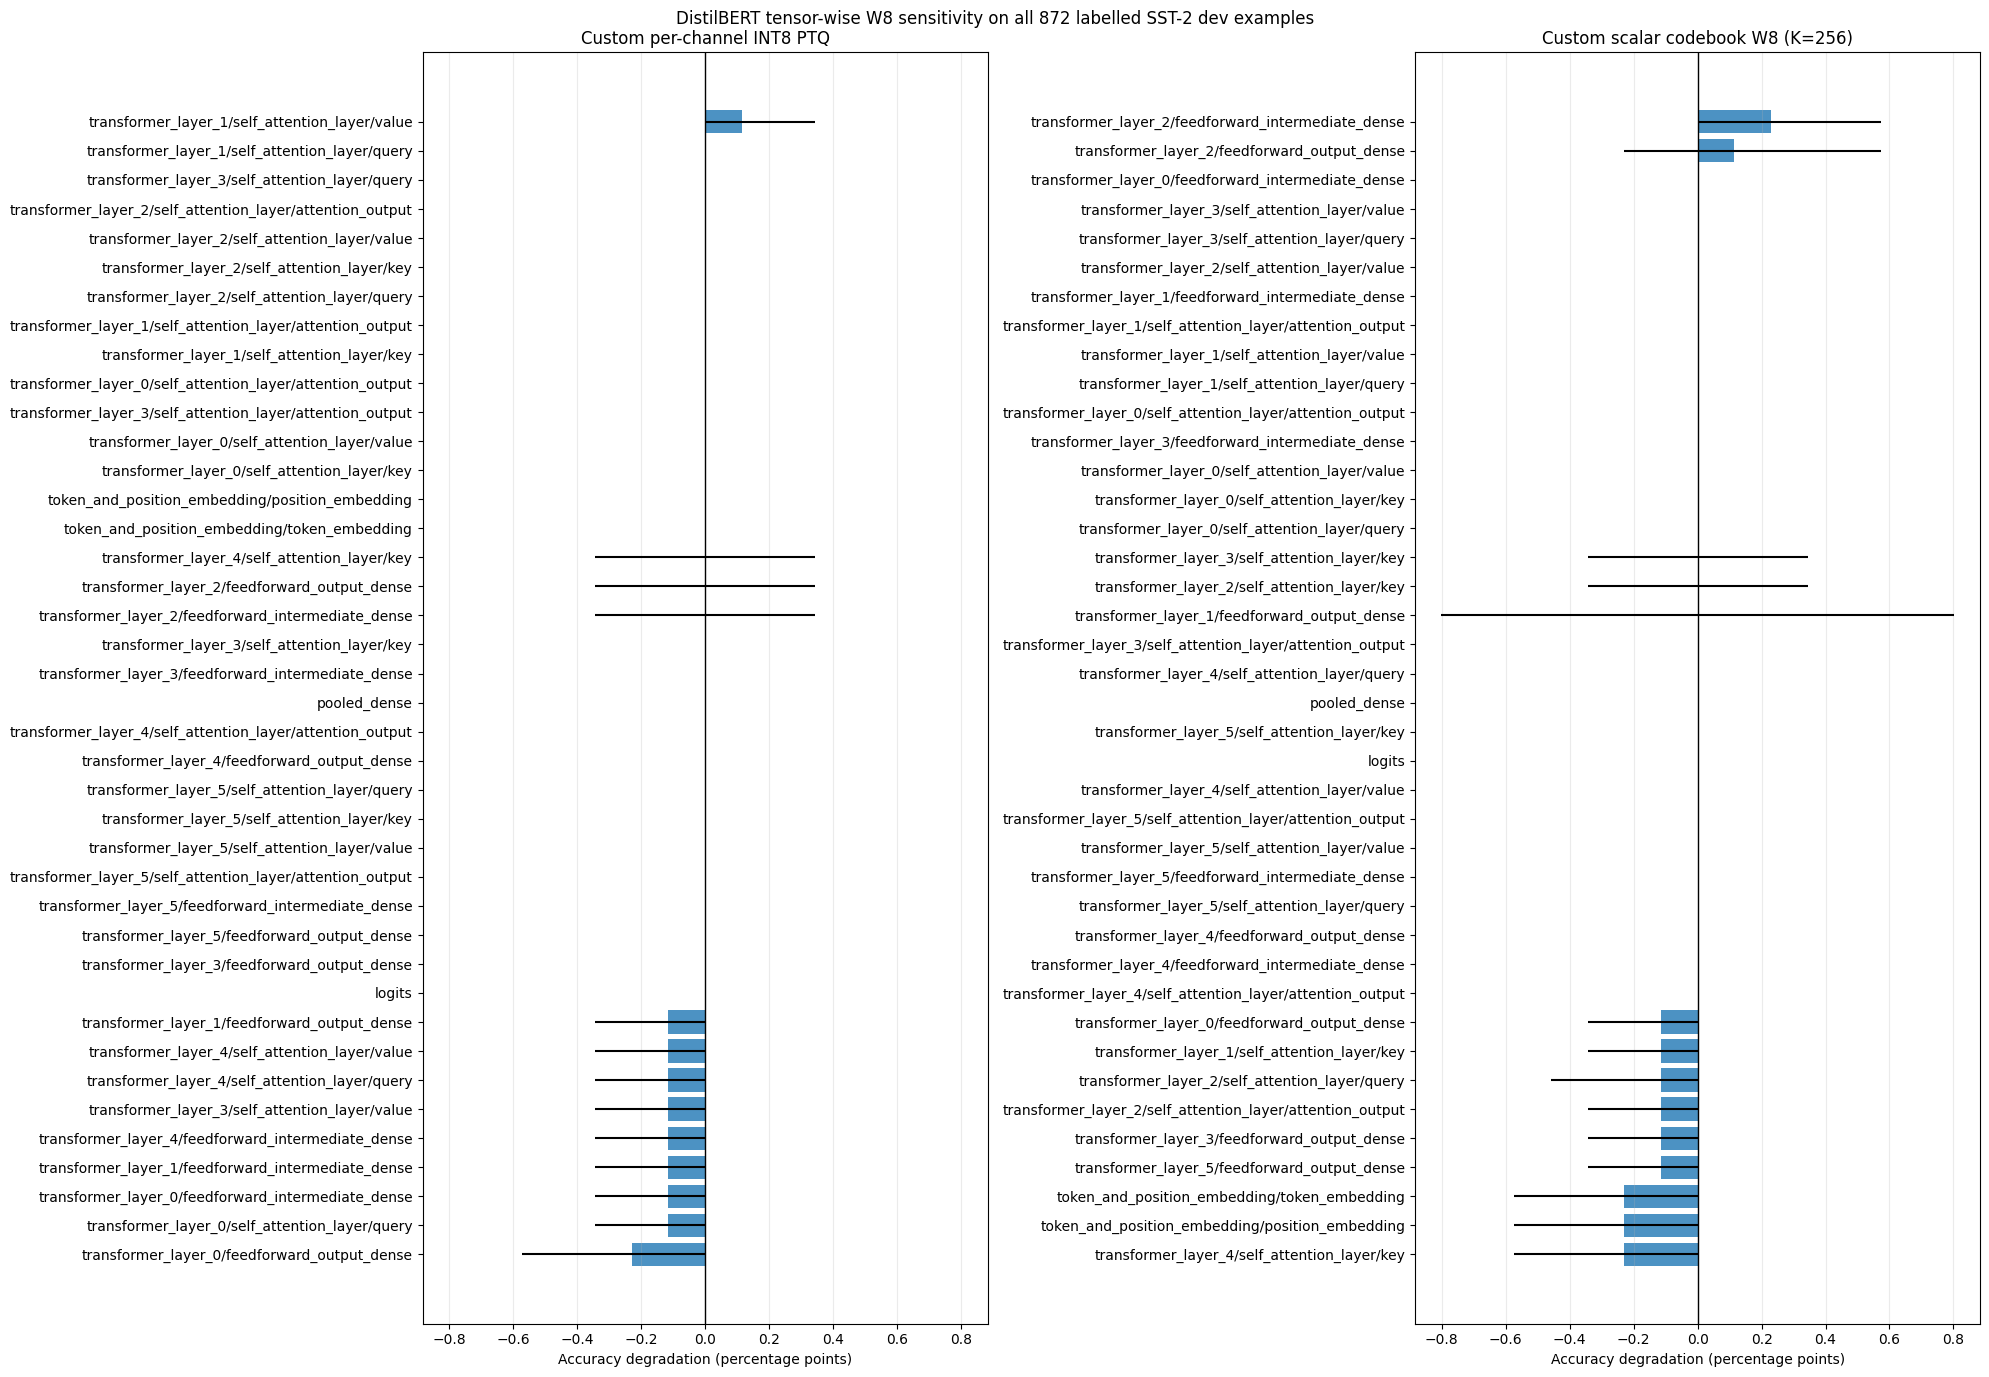

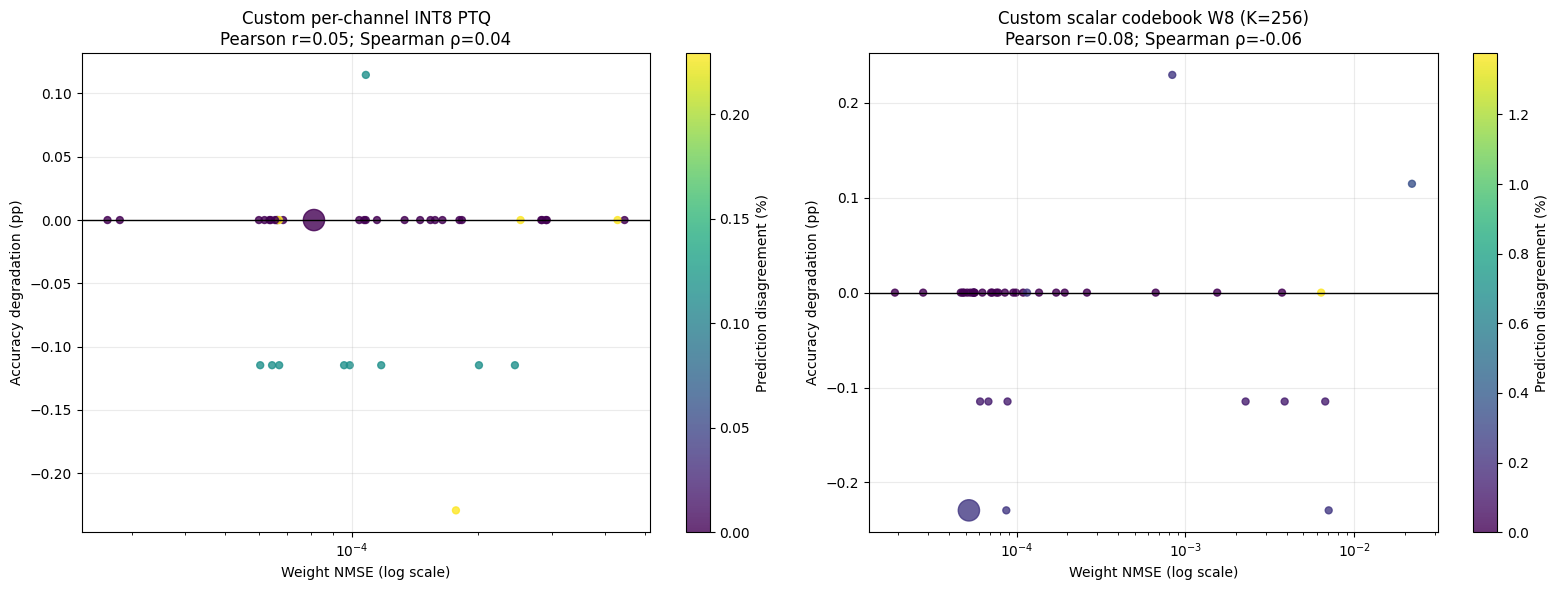

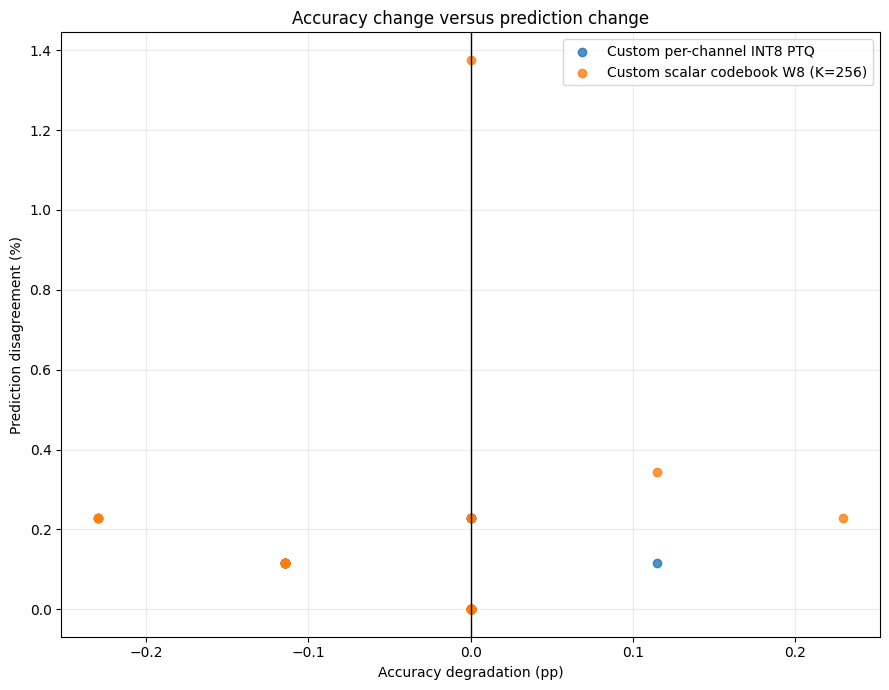

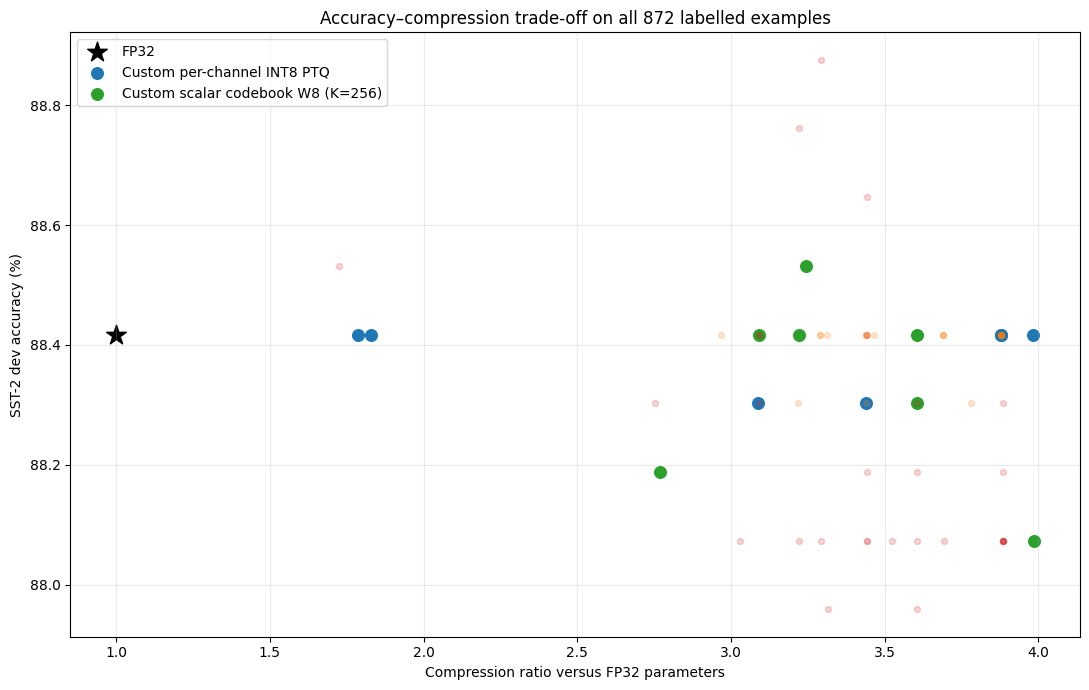

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 14), sharex=True)
for axis, (method, label) in zip(axes, METHODS.items()):
    group = ranked_results[ranked_results.method == method].sort_values("accuracy_degradation_pp")
    lower = group.accuracy_degradation_pp - group.bootstrap_ci_low_pp
    upper = group.bootstrap_ci_high_pp - group.accuracy_degradation_pp
    axis.barh(group.module, group.accuracy_degradation_pp, xerr=[lower, upper], alpha=0.8)
    axis.axvline(0, color="black", linewidth=1)
    axis.set_title(label)
    axis.set_xlabel("Accuracy degradation (percentage points)")
    axis.grid(axis="x", alpha=0.25)
fig.suptitle("DistilBERT tensor-wise W8 sensitivity on all 872 labelled SST-2 dev examples")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure1_tensor_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for axis, (method, label) in zip(axes, METHODS.items()):
    group = layerwise_results[layerwise_results.method == method]
    scatter = axis.scatter(group.weight_nmse, group.accuracy_degradation_pp, s=np.maximum(25, group.parameter_count / 100_000), c=group.prediction_disagreement_percent, cmap="viridis", alpha=0.8)
    corr = correlation_table[(correlation_table.method == method) & (correlation_table.error_metric == "weight_nmse") & (correlation_table.response_metric == "accuracy_degradation_pp")].iloc[0]
    axis.set_xscale("log")
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(f"{label}\nPearson r={corr.pearson_r:.2f}; Spearman ρ={corr.spearman_rho:.2f}")
    axis.set_xlabel("Weight NMSE (log scale)")
    axis.set_ylabel("Accuracy degradation (pp)")
    axis.grid(alpha=0.25)
    fig.colorbar(scatter, ax=axis, label="Prediction disagreement (%)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure2_error_vs_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axis = plt.subplots(figsize=(9, 7))
for method, label in METHODS.items():
    group = layerwise_results[layerwise_results.method == method]
    axis.scatter(group.accuracy_degradation_pp, group.prediction_disagreement_percent, label=label, alpha=0.8)
axis.axvline(0, color="black", linewidth=1)
axis.set_xlabel("Accuracy degradation (pp)")
axis.set_ylabel("Prediction disagreement (%)")
axis.set_title("Accuracy change versus prediction change")
axis.legend(); axis.grid(alpha=0.25); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure3_accuracy_vs_disagreement.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axis = plt.subplots(figsize=(11, 7))
axis.scatter([1], [fp32_accuracy * 100], marker="*", s=220, color="black", label="FP32")
for method, label in METHODS.items():
    group = nonrandom_results[nonrandom_results.method == method]
    axis.scatter(group.compression_ratio_vs_fp32, group.accuracy_percent, s=70, label=label)
    random_group = configuration_results[(configuration_results.method == method) & configuration_results.configuration.str.startswith("random_")]
    axis.scatter(random_group.compression_ratio_vs_fp32, random_group.accuracy_percent, s=18, alpha=0.2)
axis.set_xlabel("Compression ratio versus FP32 parameters")
axis.set_ylabel("SST-2 dev accuracy (%)")
axis.set_title("Accuracy–compression trade-off on all 872 labelled examples")
axis.legend(); axis.grid(alpha=0.25); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure4_accuracy_compression_tradeoff.png", dpi=180, bbox_inches="tight")
plt.show()

## 11. Save final tables and reproducibility record

In [15]:
ranked_results.to_csv(OUTPUT_DIR / "final_ranked_tensor_sensitivity.csv", index=False)
candidate_table.to_csv(OUTPUT_DIR / "common_tensor_coverage.csv", index=False)
metadata = {
    "model_checkpoint": str(MODEL_PATH),
    "checkpoint_modified_time": MODEL_PATH.stat().st_mtime,
    "dataset": "GLUE SST-2 complete labelled development split",
    "evaluation_examples": NUM_EVALUATION_EXAMPLES,
    "preset": PRESET, "sequence_length": SEQUENCE_LENGTH,
    "random_seed": RANDOM_SEED, "batch_size": BATCH_SIZE,
    "methods": METHODS,
    "ptq": {"bits": 8, "symmetric": True, "per_channel": PTQ_PER_CHANNEL},
    "codebook": {"assignment_bits": 8, "codebook_size": CODEBOOK_SIZE, "vector_dim": CODEBOOK_VECTOR_DIM, "codebook_dtype": str(CODEBOOK_DTYPE), "iterations": CODEBOOK_ITERATIONS, "max_samples": CODEBOOK_MAX_SAMPLES},
    "candidate_policy": "floating rank>=2 tensors ending /kernel or /embeddings; attention biases excluded",
    "common_quantized_tensors": len(candidate_table),
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "random_control_repetitions": RANDOM_CONTROL_REPETITIONS,
    "top_k_values": TOP_K_VALUES,
    "activations_quantized": False, "fake_quantization_used": False,
    "selection_bias_warning": "Selective configurations are exploratory because ranking and evaluation use the same SST-2 dev split.",
    "tensorflow_version": tf.__version__, "keras_version": keras.__version__,
    "scipy_version": scipy.__version__, "python_version": sys.version,
    "hardware": platform.platform(), "cache_version": CACHE_VERSION,
}
(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(metadata, indent=2, default=str))
print(f"All results saved under: {OUTPUT_DIR}")
print("Every accuracy and disagreement value used all 872 labelled SST-2 dev examples.")

All results saved under: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/distilbert_full_layer_sensitivity
Every accuracy and disagreement value used all 872 labelled SST-2 dev examples.


## Interpretation rules

- Positive degradation means quantization reduced accuracy; small negative values are not proof of improved generalization.
- Do not add individual tensor drops to predict full-model degradation because errors interact.
- The reconstructed Keras models do not demonstrate an indexed-codebook or integer execution runtime. Storage values describe the mathematical representations, including scale/codebook overhead.
- SST-2 dev contains only 872 examples, so accuracy changes occur in increments of approximately 0.115 percentage points and confidence intervals may be wide.
- For confirmatory selective-precision claims, rank tensors using held-out training data and reserve the development split for final evaluation.